# Exercise:


### 1. Set up early stopping criteria.
### 2. Try different optimizers.
### 3. Modify the network to overfit.
### 4. Apply regularization.
### 5. Apply data augmentation.


### Import relevant packages

In [54]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


### Download training data from open datasets

Note: to do early stopping we will need a validation set.
Also I load just 5000 samples for train and 1000 for val to make everything go faster :-)



In [55]:
from torchvision import datasets
from torchvision.transforms import ToTensor

training_data = datasets.CIFAR10(
    root=".",
    train=True,
    download=False,
    transform=ToTensor(),
)

val_data = datasets.CIFAR10(
    root=".",
    train=False,
    download=False,
    transform=ToTensor(),
)

print(len(training_data))
print(len(val_data))

classes = training_data.classes

50000
10000


In [56]:
# drop data to run faster
training_data, _ = torch.utils.data.random_split(training_data, [30000, 20000])
val_data, _ = torch.utils.data.random_split(val_data, [5000, 5000])


### Check some of the properties of the data set

In [57]:
print(classes)

num_training_samples = len(training_data)
print(f"Number of samples in the training data: {num_training_samples}")

num_val_samples = len(val_data)
print(f"Number of samples in the validation set: {num_val_samples}")


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of samples in the training data: 30000
Number of samples in the validation set: 5000


### Setting up the data sets for training and valing

Shape of X [N, C, H, W]: torch.Size([64, 3, 32, 32])
Shape of y: torch.Size([64]) torch.int64


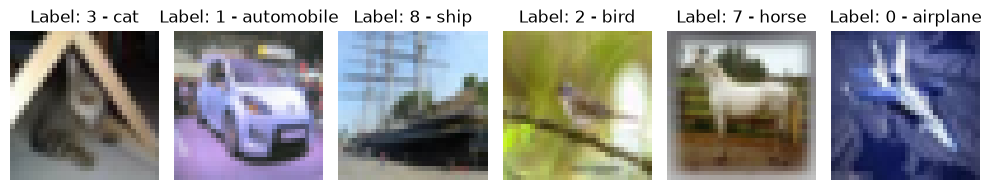

In [58]:
batch_size = 64 # we will talk about it later

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
val_dataloader = DataLoader(val_data, batch_size=batch_size)

for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")

    fig, axes = plt.subplots(1, 6, figsize=(10, 10))
    axes = axes.flatten()

    for i in range(6):
        img = X[i].squeeze().permute(1,2,0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(f"Label: {y[i]} - {classes[y[i]]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    break

### Defining a simple convolutional network architecture

| Layer type   | size    | Output channels  | Stride |
|--------------|---------|------------------|--------|
| conv         | 5x5     | 6                | 1      |
| relu         |     |                  |       |
| pool         | 2x2     |                  | 2      |
| conv         | 5x5     | 16               | 1      |
| relu         |     |                  |       |
| pool         | 2x2     |                  | 2      |
| fully connected   |      | 256               |       |
| relu         |     |                  |       |
| fully connected   |      | 120               |       |
| relu         |     |                  |       |
| fully connected   |      | 84               |       |
| relu         |     |                  |       |
| fully connected   |      | 10               |       |




Another way of visualizing the architecture

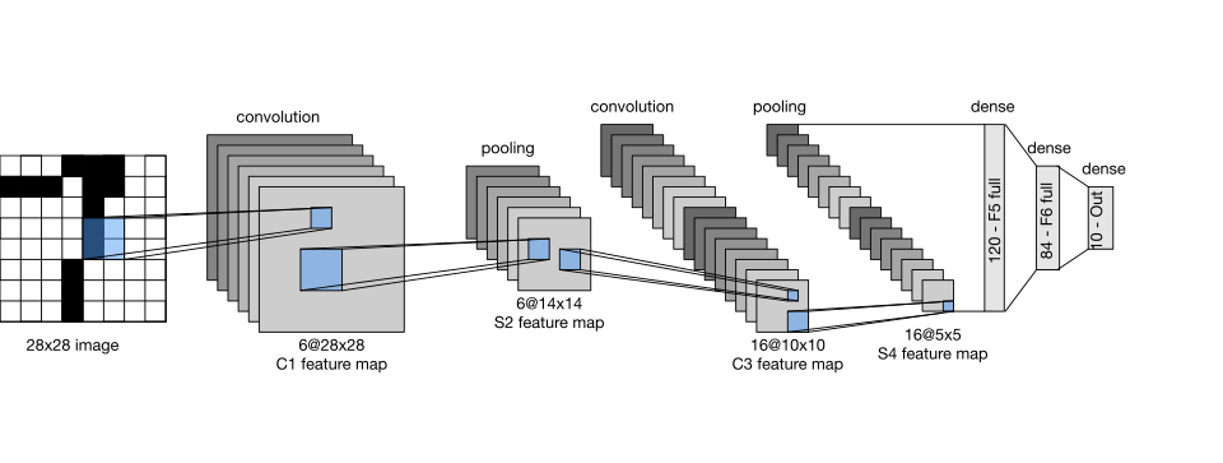

In [59]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda" if torch.cuda.is_available()
     else "cpu"
)
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5, stride=1, padding='valid')
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding='valid')
        self.relu  = nn.ReLU(inplace=True)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc1   = nn.Linear(400, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x):
      x = self.conv1(x)
      x = self.relu(x)
      x = self.pool(x)
      x = self.conv2(x)
      x = self.relu(x)
      x = self.pool(x)
      x = self.flatten(x)
      x = self.fc1(x)
      x = self.relu(x)
      x = self.fc2(x)
      x = self.relu(x)
      x = self.fc3(x)
      return x

model = NeuralNetwork().to(device)
print(model)


Using cpu device
NeuralNetwork(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=valid)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1), padding=valid)
  (relu): ReLU(inplace=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


### Defining a loss-function

Let’s use a Classification Cross-Entropy loss SGD.
Our labels are one-hot encoded, which means that for each image, we have a target vector with 10 entries (one for each class).
This target vector contains only zeros except for the entry of the class to which the image belongs.

\begin{equation}
H(y,\hat y) = -\sum_j y_j \cdot log(\hat y_j)
\end{equation}

$j \in \{1, 2, \dots, n_{\text{classes}}\}$ and $\hat{y}_j = \begin{cases}
    1 & \text{if } j = \text{true class}, \\
    0 & \text{otherwise}
\end{cases}$

Explanation: Let’s assume a simple case where we have three classes. The true label vector y for a given sample is [0, 0, 1] (indicating class 3 is the correct label), and the model outputs a probability distribution p = [0.1, 0.3, 0.6].

\begin{equation}
\text{Loss} = -[0 \times \log(0.1) + 0 \times \log(0.3) + 1 \times \log(0.6)] = -\log(0.6) = 0.51
\end{equation}



# One hot encoding
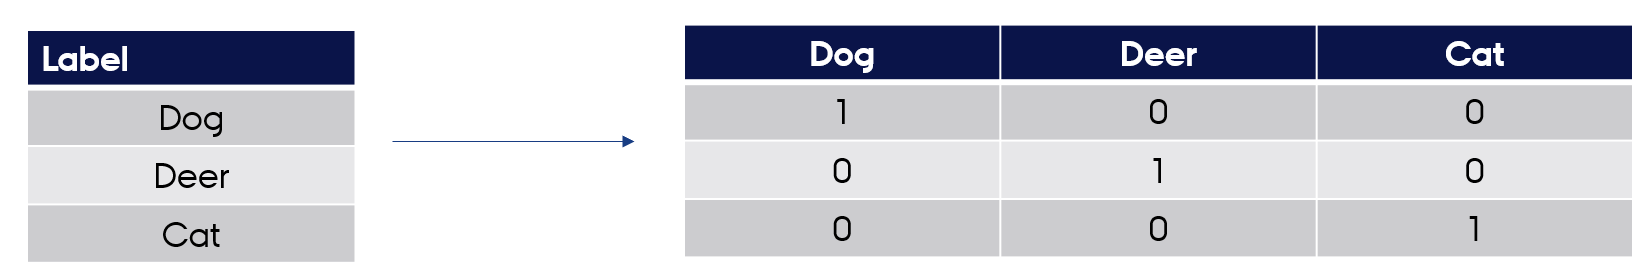

In [60]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3) # Let's use stocastic gradient descent (We will talk about it in the coming weeks)

In [ ]:
train_losses = []
train_accuracies = []

def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss, correct = 0, 0  # Track the total loss for the epoch

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        total_loss += loss.item()  # Accumulate loss

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Calculate accuracy
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    avg_loss = total_loss / len(dataloader)  # Calculate average loss for the epoch
    avg_accuracy = correct / size

    train_losses.append(avg_loss)  # Store the average loss for the epoch
    train_accuracies.append(avg_accuracy) # Store the average accuracy for the epoch

    print(f"Train loss: {avg_loss:>7f}, Accuracy: {(100*avg_accuracy):>0.1f}%")


In [62]:
val_losses = []
val_accuracies = []

def val(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    val_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            val_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    val_loss /= num_batches
    correct /= size
    val_losses.append(val_loss)  # Store the val loss for the epoch
    val_accuracies.append(correct)

    print(f"val Error: \n Avg loss: {val_loss:>8f}, Accuracy: {(100*correct):>0.1f}% \n")
    return val_loss

In [63]:
epochs = 300
patience = 5
best_loss = float('inf')
early_stopping_counter = 0

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    current_val_loss = val(val_dataloader, model, loss_fn)

    if current_val_loss < best_loss:
        best_loss = current_val_loss  # Update best loss
        early_stopping_counter = 0  # Reset counter
        print(f"val loss improved to {best_loss:.6f}, saving model...")
        torch.save(model.state_dict(), "best_model.pth")  # Save best model
    else:
        early_stopping_counter += 1
        print(f"No improvement in val loss. Early stopping counter: {early_stopping_counter}/{patience}")

    # If the patience counter reaches the patience threshold, stop training
    if early_stopping_counter >= patience:
        print("Early stopping triggered. Stopping training.")
        break

print("Done!")



Epoch 1
-------------------------------
loss: 2.315805  [   64/30000]
loss: 2.306730  [ 6464/30000]
loss: 2.314156  [12864/30000]


KeyboardInterrupt: 

# Check the performance of the network through train and val loss and accuracy curves

Write your code below to plot the training and val loss and accuracy for each epoch.

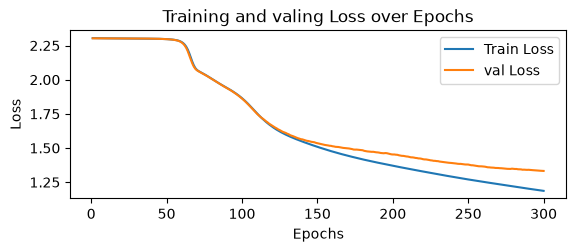

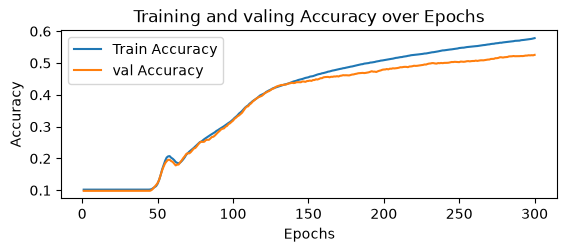

In [ ]:
plt.subplot(2,1,1)
plt.plot(range(1, epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, epochs+1), val_losses, label="val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and valing Loss over Epochs")
plt.legend()
plt.show()

plt.subplot(2,1,2)
plt.plot(range(1, epochs+1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, epochs+1), val_accuracies, label="val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and valing Accuracy over Epochs")
plt.legend()
plt.show()


# Check result for one image

Predicted: "frog", Actual: "automobile"


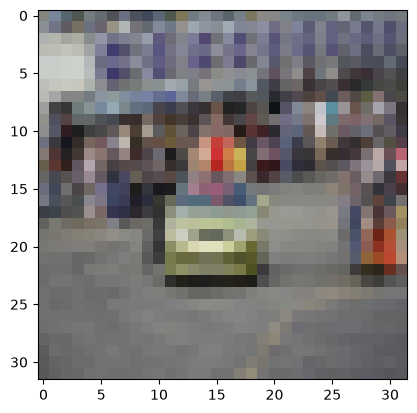

In [ ]:
model.eval()
idx = 0
x, y = val_data[idx][0], val_data[idx][1]
plt.imshow(x.permute(1,2,0))
with torch.no_grad():
    x = x.to(device)
    pred = model(x.unsqueeze(0))
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')


### Another optimizer

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

model_v2 = NeuralNetwork().to(device)
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=1e-3) # Let's use Adam optimizer , keeping all other parameters as default
patience = 5
best_loss = float('inf')
early_stopping_counter = 0

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model_v2, loss_fn, optimizer_v2)
    current_val_loss = val(val_dataloader, model_v2, loss_fn)

    if current_val_loss < best_loss:
        best_loss = current_val_loss  # Update best loss
        early_stopping_counter = 0  # Reset counter
        print(f"val loss improved to {best_loss:.6f}, saving model...")
        torch.save(model.state_dict(), "best_model.pth")  # Save best model
    else:
        early_stopping_counter += 1
        print(f"No improvement in val loss. Early stopping counter: {early_stopping_counter}/{patience}")

    # If the patience counter reaches the patience threshold, stop training
    if early_stopping_counter >= patience:
        print("Early stopping triggered. Stopping training.")
        break

print("Done!")


Epoch 1
-------------------------------
loss: 2.309372  [   64/30000]
loss: 1.993874  [ 6464/30000]
loss: 1.837872  [12864/30000]
loss: 1.830125  [19264/30000]
loss: 1.693803  [25664/30000]
Train loss: 1.854004, Accuracy: 30.4%
val Error: 
 Avg loss: 1.659342, Accuracy: 40.0% 

val loss improved to 1.659342, saving model...
Epoch 2
-------------------------------
loss: 1.550446  [   64/30000]
loss: 1.679765  [ 6464/30000]
loss: 1.575278  [12864/30000]
loss: 1.678442  [19264/30000]
loss: 1.664784  [25664/30000]
Train loss: 1.608108, Accuracy: 41.0%
val Error: 
 Avg loss: 1.522122, Accuracy: 44.0% 

val loss improved to 1.522122, saving model...
Epoch 3
-------------------------------
loss: 1.457516  [   64/30000]
loss: 1.578177  [ 6464/30000]
loss: 1.529007  [12864/30000]
loss: 1.564585  [19264/30000]
loss: 1.520793  [25664/30000]
Train loss: 1.503161, Accuracy: 45.4%
val Error: 
 Avg loss: 1.453118, Accuracy: 46.9% 

val loss improved to 1.453118, saving model...
Epoch 4
--------------

Plotting the loss

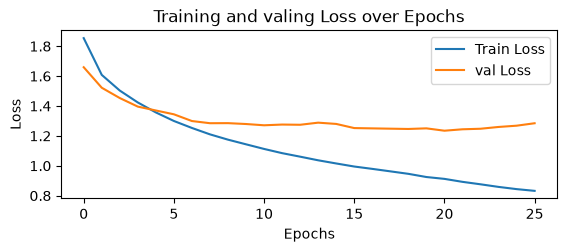

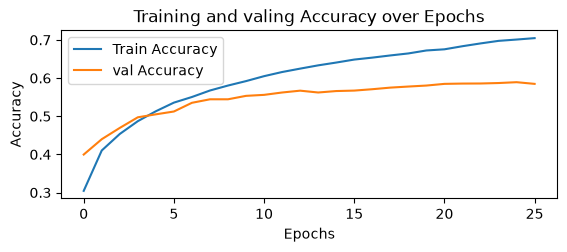

In [ ]:
plt.subplot(2,1,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and valing Loss over Epochs")
plt.legend()
plt.show()

plt.subplot(2,1,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and valing Accuracy over Epochs")
plt.legend()
plt.show()



Model to overfit

In [ ]:
# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 256, kernel_size=5, stride=1, padding='valid')
        self.conv2 = nn.Conv2d(256, 512, kernel_size=5, padding='valid')
        self.relu  = nn.ReLU(inplace=True)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc1   = nn.Linear(12800, 1280)
        self.fc2   = nn.Linear(1280, 512)
        self.fc3   = nn.Linear(512, 10)

    def forward(self, x):
      x = self.conv1(x)
      x = self.relu(x)
      x = self.pool(x)
      x = self.conv2(x)
      x = self.relu(x)
      x = self.pool(x)
      x = self.flatten(x)
      x = self.fc1(x)
      x = self.relu(x)
      x = self.fc2(x)
      x = self.relu(x)
      x = self.fc3(x)
      return x

model_v3 = NeuralNetwork().to(device)


In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epochs = 300

#model_v2 = NeuralNetwork().to(device)

optimizer_v3 = torch.optim.Adam(model_v3.parameters(), lr=1e-3) # Let's use Adam optimizer , keeping all other parameters as default
patience = 5
best_loss = float('inf')
early_stopping_counter = 0

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model_v3, loss_fn, optimizer_v3)
    current_val_loss = val(val_dataloader, model_v3, loss_fn)

    if current_val_loss < best_loss:
        best_loss = current_val_loss  # Update best loss
        early_stopping_counter = 0  # Reset counter
        print(f"val loss improved to {best_loss:.6f}, saving model...")
        torch.save(model.state_dict(), "best_model.pth")  # Save best model
    else:
        early_stopping_counter += 1
        print(f"No improvement in val loss. Early stopping counter: {early_stopping_counter}/{patience}")

    # If the patience counter reaches the patience threshold, stop training
    if early_stopping_counter >= patience:
        print("Early stopping triggered. Stopping training.")
        break

print("Done!")

Epoch 1
-------------------------------
loss: 2.298725  [   64/30000]


KeyboardInterrupt: 

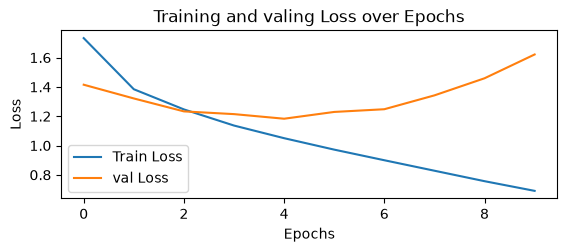

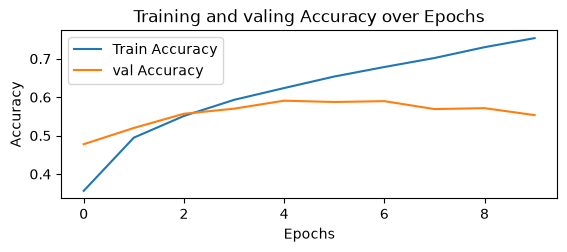

In [ ]:
plt.subplot(2,1,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and valing Loss over Epochs")
plt.legend()
plt.show()

plt.subplot(2,1,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and valing Accuracy over Epochs")
plt.legend()
plt.show()

adding L2 regularization

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

model_v4 = NeuralNetwork().to(device)
# By specifiyng the weight decay to 0.01 this gives us L2 regularization
optimizer_v4 = torch.optim.Adam(model_v4.parameters(), lr=1e-3, weight_decay = 0.01) # Let's use Adam optimizer , keeping all other parameters as default
patience = 5
best_loss = float('inf')
early_stopping_counter = 0

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model_v4, loss_fn, optimizer_v4)
    current_val_loss = val(val_dataloader, model_v4, loss_fn)

    if current_val_loss < best_loss:
        best_loss = current_val_loss  # Update best loss
        early_stopping_counter = 0  # Reset counter
        print(f"val loss improved to {best_loss:.6f}, saving model...")
        #torch.save(model.state_dict(), "best_model.pth")  # Save best model
    else:
        early_stopping_counter += 1
        print(f"No improvement in val loss. Early stopping counter: {early_stopping_counter}/{patience}")

    # If the patience counter reaches the patience threshold, stop training
    if early_stopping_counter >= patience:
        print("Early stopping triggered. Stopping training.")
        break

print("Done!")

plt.subplot(2,1,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and valing Loss over Epochs")
plt.legend()
plt.show()

plt.subplot(2,1,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and valing Accuracy over Epochs")
plt.legend()
plt.show()

Epoch 1
-------------------------------
loss: 2.299056  [   64/30000]
loss: 1.918685  [ 6464/30000]
loss: 1.644163  [12864/30000]
loss: 1.581389  [19264/30000]
loss: 1.532756  [25664/30000]
Train loss: 1.813929, Accuracy: 31.3%
val Error: 
 Avg loss: 1.593874, Accuracy: 40.6% 

val loss improved to 1.593874, saving model...
Epoch 2
-------------------------------
loss: 1.540280  [   64/30000]
loss: 1.373637  [ 6464/30000]
loss: 1.456523  [12864/30000]
loss: 1.423786  [19264/30000]
loss: 1.412047  [25664/30000]
Train loss: 1.510947, Accuracy: 43.9%
val Error: 
 Avg loss: 1.441350, Accuracy: 46.7% 

val loss improved to 1.441350, saving model...
Epoch 3
-------------------------------
loss: 1.295693  [   64/30000]
loss: 1.314339  [ 6464/30000]
loss: 1.415677  [12864/30000]
loss: 1.356147  [19264/30000]
loss: 1.350239  [25664/30000]
Train loss: 1.424460, Accuracy: 47.5%
val Error: 
 Avg loss: 1.386505, Accuracy: 48.5% 

val loss improved to 1.386505, saving model...
Epoch 4
--------------

KeyboardInterrupt: 

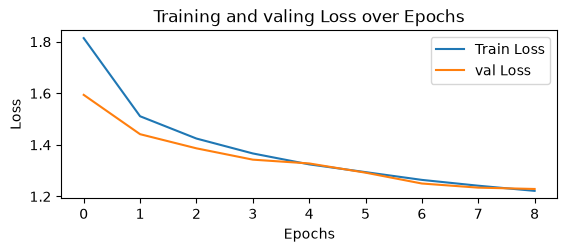

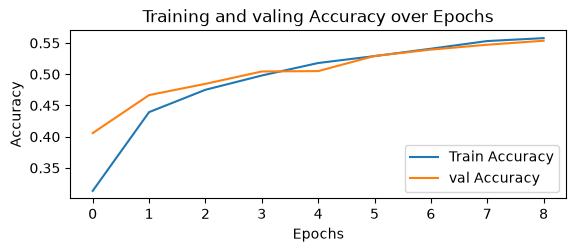

In [ ]:
plt.subplot(2,1,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and valing Loss over Epochs")
plt.legend()
plt.show()

plt.subplot(2,1,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and valing Accuracy over Epochs")
plt.legend()
plt.show()

Use data augmentation

In [70]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.RandomChoice([
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.RandomCrop(32, padding=2),
        transforms.Lambda(lambda x: x),
    ]),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
])

In [100]:
training_data = datasets.CIFAR10(
    root=".",
    train=True,
    download=False,
    transform=train_transform,
)

val_data = datasets.CIFAR10(
    root=".",
    train=False,
    download=False,
    transform=val_transform,
)


classes = training_data.classes
print(classes)

# drop data to run faster
training_data, _ = torch.utils.data.random_split(training_data, [2000, 48000])
val_data, _ = torch.utils.data.random_split(val_data, [1000, 9000])

num_training_samples = len(training_data)
print(f"Number of samples in the training data: {num_training_samples}")

num_val_samples = len(val_data)
print(f"Number of samples in the validation set: {num_val_samples}")

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of samples in the training data: 2000
Number of samples in the validation set: 1000


In [101]:
batch_size = 64

train_dataloader = DataLoader(
    training_data,
    batch_size=batch_size,
    shuffle=True
)

val_dataloader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)

Show the augmentations

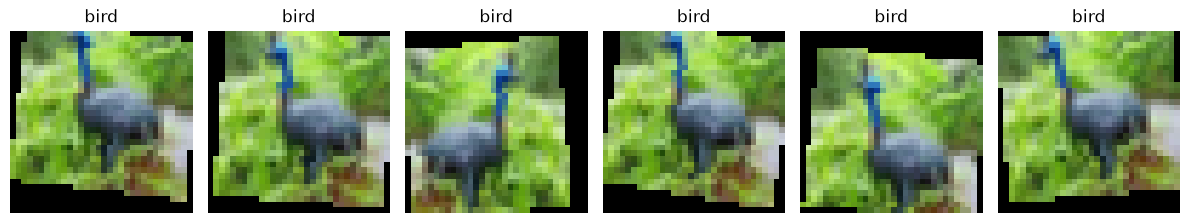

In [102]:
# Take one image from the original dataset
original_data = datasets.CIFAR10(
    root=".",
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)

image, label = original_data[6]

# Apply augmentation several times
augment = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(10),
])

fig, axes = plt.subplots(1, 6, figsize=(12, 3))

for i in range(6):

    augmented = augment(image)

    axes[i].imshow(augmented.permute(1, 2, 0))
    axes[i].set_title(classes[label])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

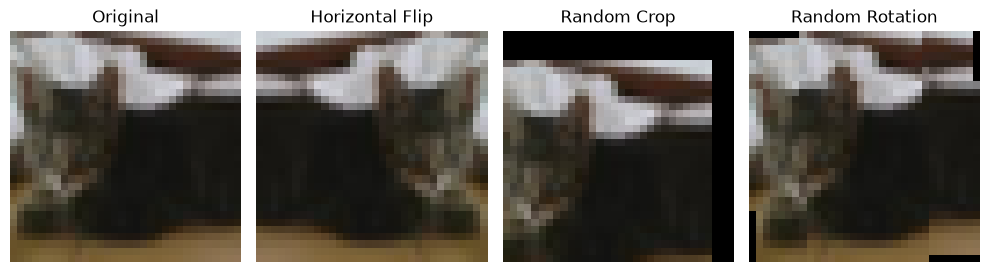

In [103]:
# show each augmentation separately

original_data = datasets.CIFAR10(
    root=".",
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)

image, label = original_data[9]

# Define each augmentation separately
horizontal_flip = transforms.RandomHorizontalFlip(p=1.0)
random_crop = transforms.RandomCrop(32, padding=4)
random_rotation = transforms.RandomRotation(10)

# Apply each augmentation
flip_image = horizontal_flip(image)
crop_image = random_crop(image)
rotation_image = random_rotation(image)

# Plot
fig, axes = plt.subplots(1, 4, figsize=(10, 3))

images = [
    image,
    flip_image,
    crop_image,
    rotation_image
]

titles = [
    "Original",
    "Horizontal Flip",
    "Random Crop",
    "Random Rotation"
]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()



# Lets go back to the original model architecture

In [104]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda" if torch.cuda.is_available()
     else "cpu"
)
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5, stride=1, padding='valid')
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding='valid')
        self.relu  = nn.ReLU(inplace=True)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc1   = nn.Linear(400, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x):
      x = self.conv1(x)
      x = self.relu(x)
      x = self.pool(x)
      x = self.conv2(x)
      x = self.relu(x)
      x = self.pool(x)
      x = self.flatten(x)
      x = self.fc1(x)
      x = self.relu(x)
      x = self.fc2(x)
      x = self.relu(x)
      x = self.fc3(x)
      return x

model = NeuralNetwork().to(device)
print(model)


Using cpu device
NeuralNetwork(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=valid)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1), padding=valid)
  (relu): ReLU(inplace=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


Now we are training like before but with different augmentations for each epoch (aka the model sees more "different" data although we dropped a lot of the data)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3) # Let's use stocastic gradient descent (We will talk about it in the coming weeks)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epochs = 500
patience = 5
best_loss = float('inf')
early_stopping_counter = 0

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    current_val_loss = val(val_dataloader, model, loss_fn)

    if current_val_loss < best_loss:
        best_loss = current_val_loss  # Update best loss
        early_stopping_counter = 0  # Reset counter
        print(f"val loss improved to {best_loss:.6f}, saving model...")
        torch.save(model.state_dict(), "best_model.pth")  # Save best model
    else:
        early_stopping_counter += 1
        print(f"No improvement in val loss. Early stopping counter: {early_stopping_counter}/{patience}")

    # If the patience counter reaches the patience threshold, stop training
    if early_stopping_counter >= patience:
        print("Early stopping triggered. Stopping training.")
        break

print("Done!")



Epoch 1
-------------------------------
loss: 2.317804  [   64/ 2000]
Train loss: 2.306168, Accuracy: 9.0%
val Error: 
 Avg loss: 2.303622, Accuracy: 10.0% 

val loss improved to 2.303622, saving model...
Epoch 2
-------------------------------
loss: 2.303184  [   64/ 2000]
Train loss: 2.304536, Accuracy: 9.0%
val Error: 
 Avg loss: 2.303590, Accuracy: 10.0% 

val loss improved to 2.303590, saving model...
Epoch 3
-------------------------------
loss: 2.310552  [   64/ 2000]
Train loss: 2.305598, Accuracy: 9.0%
val Error: 
 Avg loss: 2.303552, Accuracy: 10.0% 

val loss improved to 2.303552, saving model...
Epoch 4
-------------------------------
loss: 2.307779  [   64/ 2000]
Train loss: 2.305315, Accuracy: 9.0%
val Error: 
 Avg loss: 2.303520, Accuracy: 10.0% 

val loss improved to 2.303520, saving model...
Epoch 5
-------------------------------
loss: 2.297748  [   64/ 2000]
Train loss: 2.305444, Accuracy: 9.0%
val Error: 
 Avg loss: 2.303485, Accuracy: 10.0% 

val loss improved to 2

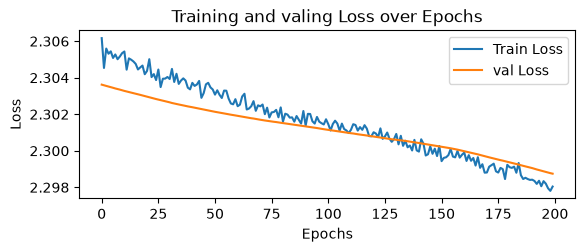

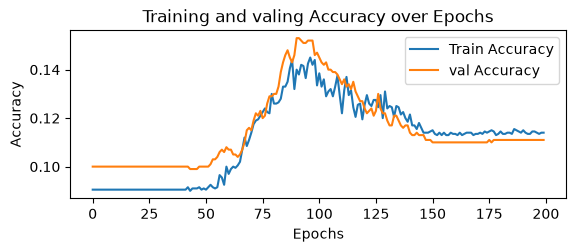

In [107]:
plt.subplot(2,1,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and valing Loss over Epochs")
plt.legend()
plt.show()

plt.subplot(2,1,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and valing Accuracy over Epochs")
plt.legend()
plt.show()

Compare to training without augmentation

In [108]:
# use no augmentation for training and validation data
training_data = datasets.CIFAR10(
    root=".",
    train=True,
    download=False,
    transform=ToTensor()
)

val_data = datasets.CIFAR10(
    root=".",
    train=False,
    download=False,
    transform=ToTensor(),
)

classes = training_data.classes
print(classes)

# drop data to run faster
training_data, _ = torch.utils.data.random_split(training_data, [2000, 48000])
val_data, _ = torch.utils.data.random_split(val_data, [1000, 9000])

num_training_samples = len(training_data)
print(f"Number of samples in the training data: {num_training_samples}")

num_val_samples = len(val_data)
print(f"Number of samples in the validation set: {num_val_samples}")

batch_size = 64

train_dataloader = DataLoader(
    training_data,
    batch_size=batch_size,
    shuffle=True
)

val_dataloader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)

# Get cpu, gpu or mps device for training.
device = (
    "cuda" if torch.cuda.is_available()
     else "cpu"
)
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5, stride=1, padding='valid')
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding='valid')
        self.relu  = nn.ReLU(inplace=True)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc1   = nn.Linear(400, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x):
      x = self.conv1(x)
      x = self.relu(x)
      x = self.pool(x)
      x = self.conv2(x)
      x = self.relu(x)
      x = self.pool(x)
      x = self.flatten(x)
      x = self.fc1(x)
      x = self.relu(x)
      x = self.fc2(x)
      x = self.relu(x)
      x = self.fc3(x)
      return x

model = NeuralNetwork().to(device)
print(model)


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of samples in the training data: 2000
Number of samples in the validation set: 1000
Using cpu device
NeuralNetwork(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=valid)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1), padding=valid)
  (relu): ReLU(inplace=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3) # Let's use stocastic gradient descent (We will talk about it in the coming weeks)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epochs = 500
patience = 5
best_loss = float('inf')
early_stopping_counter = 0

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    current_val_loss = val(val_dataloader, model, loss_fn)

    if current_val_loss < best_loss:
        best_loss = current_val_loss  # Update best loss
        early_stopping_counter = 0  # Reset counter
        print(f"val loss improved to {best_loss:.6f}, saving model...")
    else:
        early_stopping_counter += 1
        print(f"No improvement in val loss. Early stopping counter: {early_stopping_counter}/{patience}")

    # If the patience counter reaches the patience threshold, stop training
    if early_stopping_counter >= patience:
        print("Early stopping triggered. Stopping training.")
        break

print("Done!")



Epoch 1
-------------------------------
loss: 2.312108  [   64/ 2000]
Train loss: 2.303115, Accuracy: 10.4%
val Error: 
 Avg loss: 2.301735, Accuracy: 9.8% 

val loss improved to 2.301735, saving model...
Epoch 2
-------------------------------
loss: 2.306684  [   64/ 2000]
Train loss: 2.303095, Accuracy: 10.4%
val Error: 
 Avg loss: 2.301726, Accuracy: 9.8% 

val loss improved to 2.301726, saving model...
Epoch 3
-------------------------------
loss: 2.309681  [   64/ 2000]
Train loss: 2.302742, Accuracy: 10.4%
val Error: 
 Avg loss: 2.301718, Accuracy: 9.8% 

val loss improved to 2.301718, saving model...
Epoch 4
-------------------------------
loss: 2.310070  [   64/ 2000]
Train loss: 2.302620, Accuracy: 10.4%
val Error: 
 Avg loss: 2.301711, Accuracy: 9.8% 

val loss improved to 2.301711, saving model...
Epoch 5
-------------------------------
loss: 2.310934  [   64/ 2000]
Train loss: 2.302078, Accuracy: 10.4%
val Error: 
 Avg loss: 2.301704, Accuracy: 9.8% 

val loss improved to 2

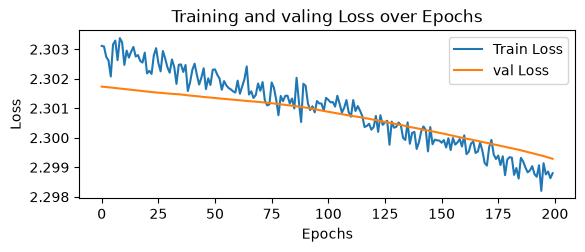

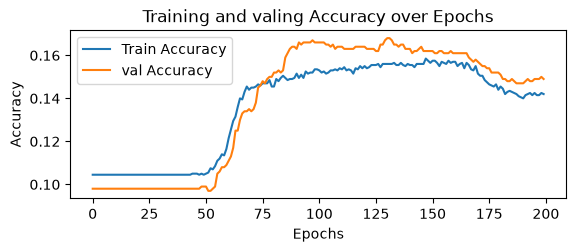

In [111]:

plt.subplot(2,1,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and valing Loss over Epochs")
plt.legend()
plt.show()

plt.subplot(2,1,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and valing Accuracy over Epochs")
plt.legend()
plt.show()